# Przygotowanie

Przygotowanie Przed rozpoczęciem pracy z notatnikiem proszę zmienić jego nazwę dodając na początku numer albumu, imię i nazwisko. {nr_albumu}_{imię}_{nazwisko}_{nazwa}

Po wykonaniu wszystkich zadań proszę przesłać wypełniony notatnik przez platformę ELF za pomocą formularza "Prześlij projekt" w odpowiedniej sekcji.

# KNN

Podobnie jak w przypadku maszyny wektorów nosnych (SVC) oraz drzew decyzyjnych, KNN może słuzyc do rozwiazywania problemów zarówno klasyfikacji, jak i regresji. Algorytm KNN jest przykładem leniwego uczenia (lazy learning), co oznacza, że nie tworzy on modelu na podstawie danych uczących. Zamiast tego, w momencie klasyfikacji nowej obserwacji, algorytm poszukuje k najbardziej podobnych przypadków w zbiorze danych treningowych i przypisuje mu etykietę tej klasy, do której należy większość jego k sąsiadów.

**Algorytm KNN może być wykorzystywany zarówno do zadań klasyfikacji, jak i regresji.**

### Skalowanie danych

Jednym z istotnych elementów implementacji algorytmu KNN jest konieczność skalowania danych. Ponieważ algorytm ten opiera się na obliczaniu odległości pomiędzy punktami danych, różnice w jednostkach lub skali poszczególnych cech mogą prowadzić do zakłamanych wyników. Dlatego zazwyczaj skalowanie danych jest niezbędne, na przykład za pomocą standaryzacji lub normalizacji.

### Metryki odległości w KNN

Metryki odległości są kluczowym elementem algorytmu KNN, ponieważ definiują sposób działania algorytmu. Istnieją różne metryki odległości, z których najczęściej używanymi są:

1. *Odległość euklidesowa*: najpopularniejsza metryka odległości, która oblicza odległość między dwoma punktami w przestrzeni euklidesowej. W przypadku dwuwymiarowej przestrzeni (2D), odległość między punktami $(x_1, y_1)$ i $(x_2, y_2)$ obliczana jest jako $\sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}$. W przestrzeni trójwymiarowej (3D), dodatkowo uwzględniana jest trzecia współrzędna.

2. *Odległość Manhattan*: oblicza sumę różnic wartości bezwzględnych między odpowiadającymi współrzędnymi punktów. W przestrzeni dwuwymiarowej, odległość między punktami $(x_1, y_1)$ i $(x_2, y_2)$ wynosi $|x_2-x_1| + |y_2-y_1|$, podczas gdy w przestrzeni trójwymiarowej dodaje się jeszcze różnicę trzeciej współrzędnej.


In [1]:
import pandas as pd
import numpy as np

## Zadanie 1

Proszę pobrać, wczytać, oraz dokonać wizualizacji danych: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Wizualizacji oraz dalszych obliczeń proszę dokonać tylko dla trzech wybranych przez siebie cech

   radius_mean  texture_mean  perimeter_mean  diagnosis
0        17.99         10.38          122.80          1
1        20.57         17.77          132.90          1
2        19.69         21.25          130.00          1
3        11.42         20.38           77.58          1
4        20.29         14.34          135.10          1


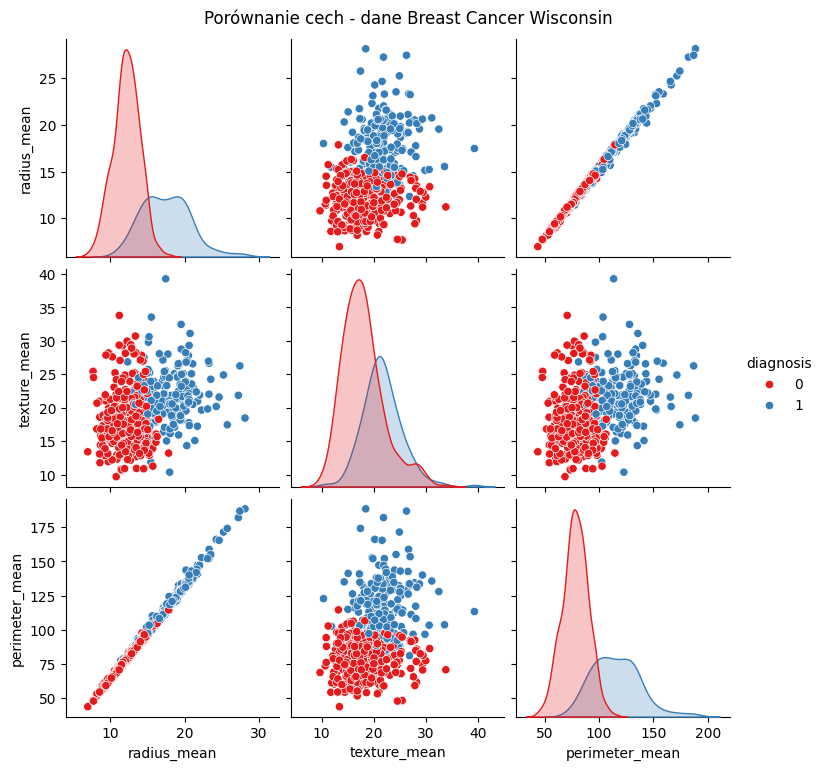

In [69]:
# YOUR CODE HERE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

file_path = 'wdbc.data'
df = pd.read_csv(file_path, header=None, names=columns)

df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})


selected_features = ['radius_mean', 'texture_mean', 'perimeter_mean']

print(df[selected_features + ['diagnosis']].head())

sns.pairplot(df[selected_features + ['diagnosis']], hue='diagnosis', palette='Set1')
plt.suptitle('Porównanie cech - dane Breast Cancer Wisconsin', y=1.02)
plt.show()


## Zadanie 2

Proszę dokonać czyszczenia danych, sprawdzić czy nie ma danych brakujących oraz dokonać skalowania danych

In [70]:
# YOUR CODE HERE
# Jeśli wszystko jest OK, to wynik to same zera.
print(df.isnull().sum())


df_clean = df.drop(columns=['id'])
# df[selected_features + ['diagnosis']]

print(df_clean.dtypes)



from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

# Skalowanie
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

df_scaled = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)



id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
diagnosis                    int64
radius_mean             

## Zadanie 3

Proszę zaimplementować algorytm KNN. Algorytm ma być w stanie dokonać klasyfikacji zarówno dla dwóch, jak i trzech cech. Parametr k ma być możliwy do podania na wejście algorytmu.

Dokładność dla k = 5: 0.9035


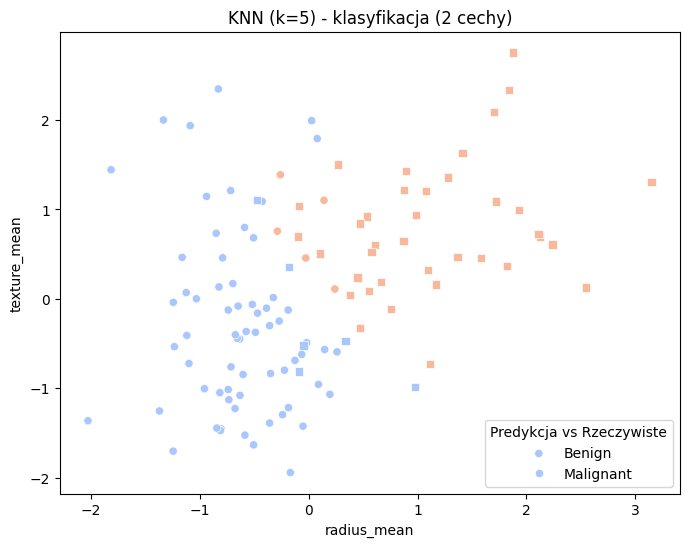

Dokładność dla k = 3: 0.9123


In [72]:
# YOUR CODE HERE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

class KNN:
    def __init__(self, k=3, metric='euclidean'):
        """
        Initialize KNN classifier
        k: number of neighbors
        metric: 'euclidean' or 'manhattan'
        """
        self.k = k
        self.metric = metric
        
    def fit(self, X, y):
        """Store training data"""
        self.X_train = X
        self.y_train = y
        
    def euclidean_distance(self, x1, x2):
        """Calculate Euclidean distance between two points"""
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def manhattan_distance(self, x1, x2):
        """Calculate Manhattan distance between two points"""
        return np.sum(np.abs(x1 - x2))
    
    def calculate_distance(self, x1, x2):
        """Calculate distance"""
        if self.metric == 'euclidean':
            return self.euclidean_distance(x1, x2)
        return self.manhattan_distance(x1, x2)
    
    def predict(self, X):
        """Make predictions for all samples"""
        predictions = []
        
        for x in X:
            distances = [self.calculate_distance(x, x_train) for x_train in self.X_train]
            
            k_indices = np.argsort(distances)[:self.k]
            
            k_nearest_labels = [self.y_train[i] for i in k_indices]
            
            most_common = Counter(k_nearest_labels).most_common(1)
            predictions.append(most_common[0][0])
            
        return np.array(predictions)



def run_knn_custom(df, features, k):

    X = df[features].values
    y = df['diagnosis'].values
    
    # Podział na zbiór treningowy i testowy
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Inicjalizacja i trenowanie modelu KNN
    # model = KNeighborsClassifier(n_neighbors=k)
    model = KNN(k=k, metric='euclidean')  # metric='manhattan'

    model.fit(X_train, y_train)

    # Predykcja i ocena
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'Dokładność dla k = {k}: {acc:.4f}')

    if len(features) == 2:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(x=X_test[:, 0], y=X_test[:, 1], hue=y_pred, palette='coolwarm', style=y_test, markers=["o", "s"])
        plt.title(f'KNN (k={k}) - klasyfikacja (2 cechy)')
        plt.xlabel(features[0])
        plt.ylabel(features[1])
        plt.legend(title="Predykcja vs Rzeczywiste", labels=["Benign", "Malignant"])
        plt.show()



run_knn_custom(df_scaled, ['radius_mean', 'texture_mean'], k=5)
run_knn_custom(df_scaled, ['radius_mean', 'texture_mean', 'perimeter_mean'], k=3)


## Zadanie 4

Proszę wytrenować model z użyciem zbiotu danych. Proszę pamiętać o odpowienim podziale na zbiór testowy i treningowy. Klasyfikator powinien być trenowany na zbiorze treningowym, a wynik jego skuteczności po trenowaniu obliczany w oparciu o zbiór testowy.

Proszę przygotować wyniki, trenując algorytm z użyciem różnych parametrów k - należy przygotować wykresy (oś pionowa określa skuteczność, pozioma wartość parametru) pokazujące jak zmienia się skuteczność działania w zależności od zastosowanego parameteru k. Proszę o przygotowanie odpowiedniego porównania (tabela), co można zaobserwować?

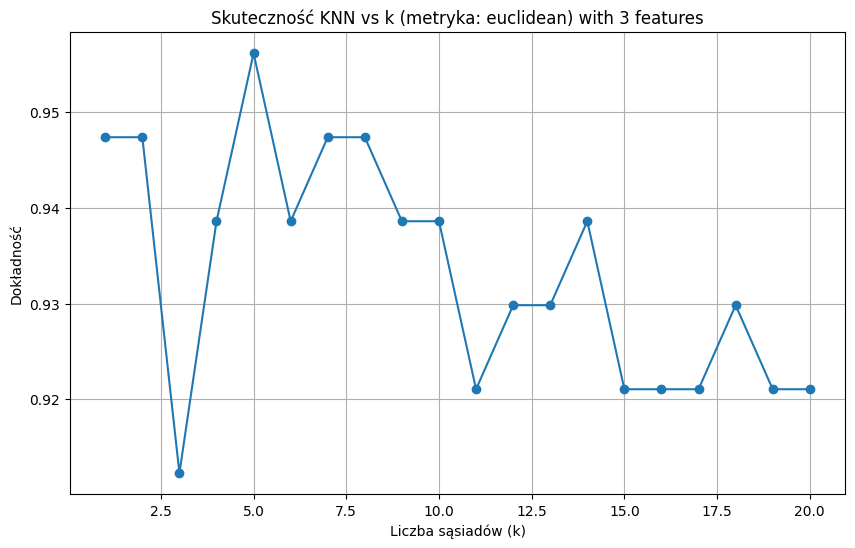

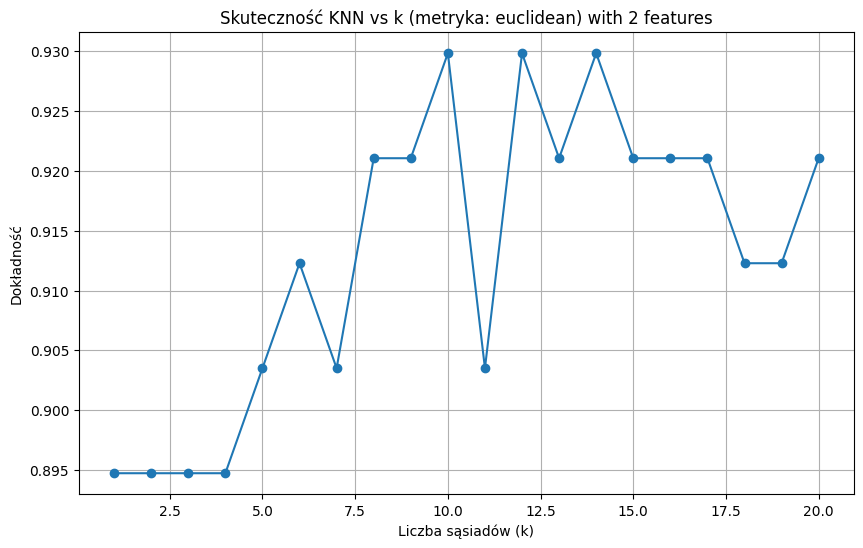

In [ ]:
#YOUR CODE HERE
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def test_knn_accuracy_for_k_range(df, features, k_range, metric='euclidean'):
    X = df[features].values
    y = df['diagnosis'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    results = []

    for k in k_range:
        model = KNN(k=k, metric=metric)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append({'k': k, 'accuracy': acc})
        # print(f"k={k}, accuracy={acc:.4f}")

    # Konwersja do DataFrame
    results_df = pd.DataFrame(results)

    # Wykres
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['k'], results_df['accuracy'], marker='o')
    plt.title(f"Skuteczność KNN vs k (metryka: {metric}) with {len(features)} features")
    plt.xlabel("Liczba sąsiadów (k)")
    plt.ylabel("Dokładność")
    plt.grid(True)
    plt.show()

    return results_df


# Zakładamy, że dane są już przeskalowane i gotowe
features = ['radius_mean', 'texture_mean', 'perimeter_mean']
k_values = range(1, 21)

results_df = test_knn_accuracy_for_k_range(df_scaled, features, k_range=k_values, metric='euclidean')



features = ['radius_mean', 'texture_mean']
k_values = range(1, 21)

results_df = test_knn_accuracy_for_k_range(df_scaled, features, k_range=k_values, metric='euclidean')


## Zadanie 5

Proszę porównać działanie zaimplementowanego algorytmu z implementacją z Scikit-learn. Proszę dokonać porównania w oparciu o szybkość oraz skuteczność działania. Jakie wnioski można wyciągnać?

In [74]:
# YOUR CODE HERE

import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
    
def compare_custom_and_sklearn_knn(df, features, k=5):


    X = df[features].values
    y = df['diagnosis'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # moja implementacja ---
    custom_model = KNN(k=k, metric='euclidean')
    
    start = time.time()
    custom_model.fit(X_train, y_train)
    y_pred_custom = custom_model.predict(X_test)
    custom_time = time.time() - start
    custom_acc = accuracy_score(y_test, y_pred_custom)

    # Sklearn ---
    sklearn_model = KNeighborsClassifier(n_neighbors=k)

    start = time.time()
    sklearn_model.fit(X_train, y_train)
    y_pred_sklearn = sklearn_model.predict(X_test)
    sklearn_time = time.time() - start
    sklearn_acc = accuracy_score(y_test, y_pred_sklearn)

    # Wyniki ---
    print(f"Porównanie KNN (k={k}):")
    print(f"Moja implementacja:     acc = {custom_acc:.4f}, czas = {custom_time:.4f} s")
    print(f"Scikit-learn:           acc = {sklearn_acc:.4f}, czas = {sklearn_time:.4f} s")

    return {
        'custom_acc': custom_acc,
        'custom_time': custom_time,
        'sklearn_acc': sklearn_acc,
        'sklearn_time': sklearn_time
    }

features = ['radius_mean', 'texture_mean', 'perimeter_mean']
compare_custom_and_sklearn_knn(df_scaled, features, k=5)


Porównanie KNN (k=5):
Moja implementacja:     acc = 0.9561, czas = 0.3336 s
Scikit-learn:           acc = 0.9561, czas = 0.0069 s


{'custom_acc': 0.956140350877193,
 'custom_time': 0.33361172676086426,
 'sklearn_acc': 0.956140350877193,
 'sklearn_time': 0.0069179534912109375}

## Zadanie 6

Proszę wyrysować krzywą ROC oraz obliczyć miarę AUC dla wytrenowanych modeli.

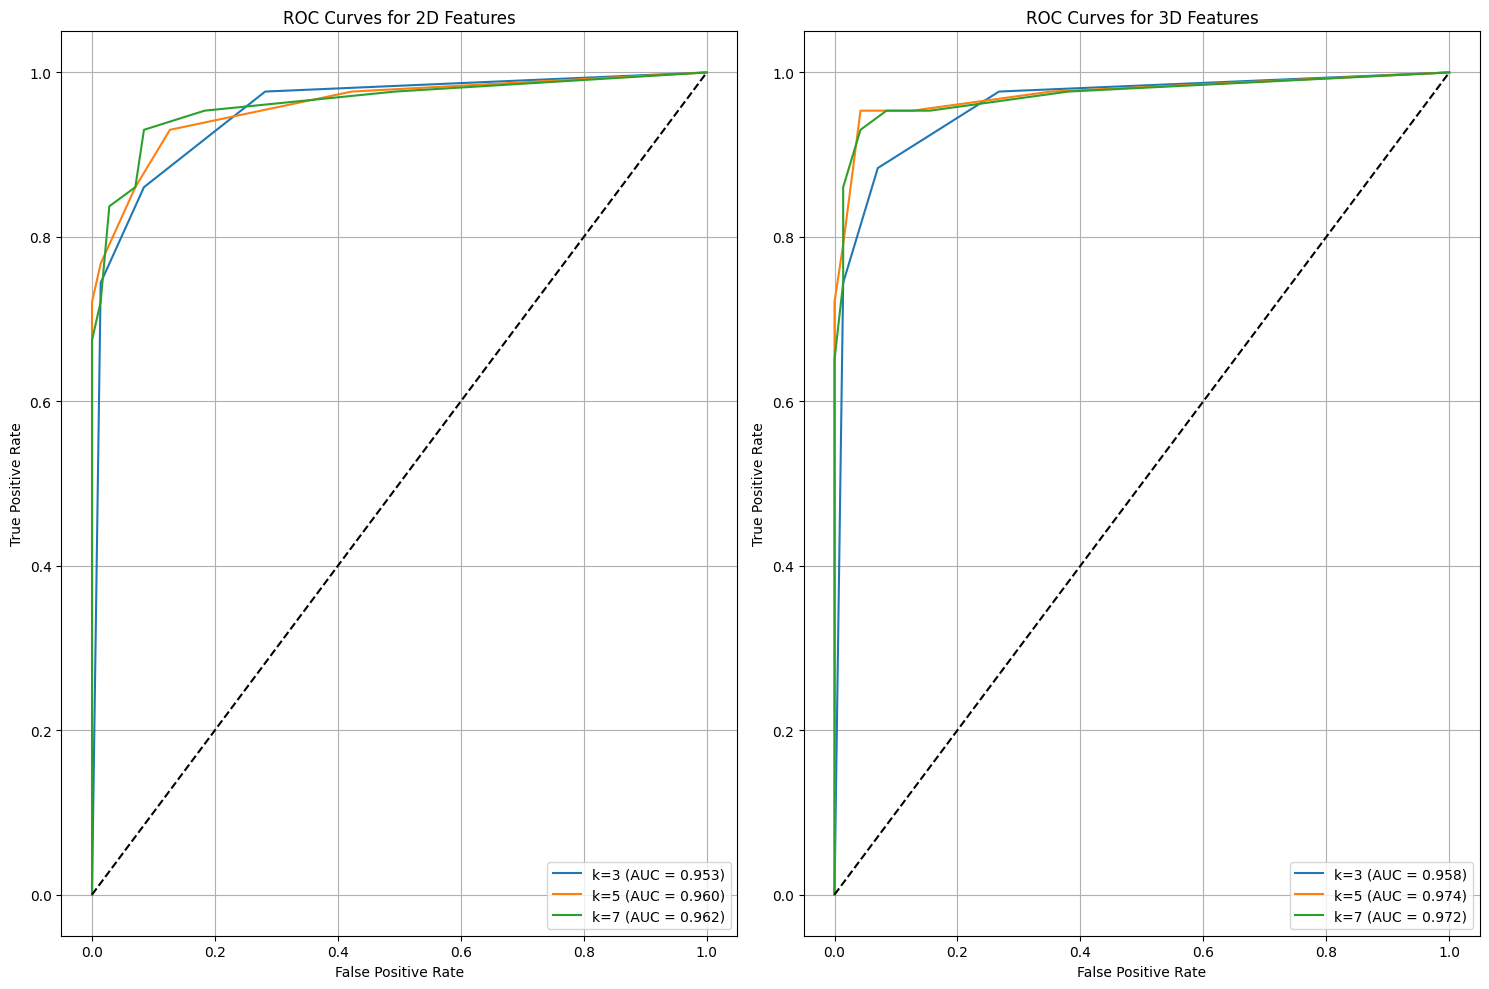


Detailed AUC Scores:

2D Features:
k=3: AUC = 0.9528
k=5: AUC = 0.9595
k=7: AUC = 0.9623

3D Features:
k=3: AUC = 0.9584
k=5: AUC = 0.9736
k=7: AUC = 0.9720


In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

features_2d = ['radius_mean', 'texture_mean']
features_3d = ['radius_mean', 'texture_mean', 'perimeter_mean']

X_2d = df_scaled[features_2d].values
X_3d = df_scaled[features_3d].values

y = df_scaled['diagnosis'].values


X_train_3d, X_test_3d, y_train_3d, y_test_3d = train_test_split(X_3d, y, test_size=0.2, random_state=42)
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)

k_values = [3, 5, 7]
dimensions = {
    '2D': (X_train_2d, X_test_2d),
    '3D': (X_train_3d, X_test_3d)
}

plt.figure(figsize=(15, 10))

for idx, (dim_name, (X_train, X_test)) in enumerate(dimensions.items()):
    plt.subplot(1, 2, idx+1)
    
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        
        if dim_name == "2d":
            y_test = y_test_2d
            y_train=y_train_2d
        else:
            y_test = y_test_3d
            y_train=y_train_3d

        knn.fit(X_train, y_train)
        y_prob = knn.predict_proba(X_test)[:, 1]
        
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f'k={k} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves for {dim_name} Features')
    plt.legend(loc='lower right')
    plt.grid(True)

plt.tight_layout()
plt.show()


print("\nDetailed AUC Scores:")


for dim_name, (X_train, X_test) in dimensions.items():
    print(f"\n{dim_name} Features:")
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        if dim_name == "2d":
            y_test = y_test_2d
            y_train=y_train_2d
        else:
            y_test = y_test_3d
            y_train=y_train_3d
        knn.fit(X_train, y_train)
        y_prob = knn.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        print(f"k={k}: AUC = {roc_auc:.4f}")
